In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv("gld_price_data.csv")

In [3]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


# Columns Overview:
* Date : Timestamp ( not use in this process)
* SPX: S&P 500 index value
* GLD: Gold ETF price (Target variable)
* USO: Crude oil ETF price
* SLV: Silver ETF price
* EUR/USD : Euro to US Dollar exchange rate

In [4]:
df.shape

(2290, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.columns.to_list()

['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']

In [16]:
df['Date'].unique()

array(['1/2/2008', '1/3/2008', '1/4/2008', ..., '5/10/2018', '5/14/2018',
       '5/16/2018'], dtype=object)

In [18]:
df['SPX'].unique()

array([1447.160034, 1411.630005, 1416.180054, ..., 2723.070068,
       2730.129883, 2725.780029])

In [21]:
df['GLD'].unique()

array([ 84.860001,  85.57    ,  85.129997, ..., 124.330002, 124.489998,
       122.5438  ])

# backup  of the dataset 

In [22]:
backup = df.copy()

In [23]:
df.drop(columns=['Date'],inplace=True)

In [24]:
df

,SPX,GLD,USO,SLV,EUR/USD
0,1447.160034,84.860001,78.470001,15.1800,1.471692
1,1447.160034,85.570000,78.370003,15.2850,1.474491
2,1411.630005,85.129997,77.309998,15.1670,1.475492
3,1416.180054,84.769997,75.500000,15.0530,1.468299
4,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...
2285,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,2730.129883,124.489998,14.380000,15.5600,1.193118


In [25]:
df.isnull().sum()

SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [26]:
df.dtypes

SPX        float64
GLD        float64
USO        float64
SLV        float64
EUR/USD    float64
dtype: object

In [27]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Outlier counts per feature:
 SPX         0
GLD         0
USO        63
SLV        10
EUR/USD     0
dtype: int64

Basic Statistics:
                SPX          GLD          USO          SLV      EUR/USD
count  2290.000000  2290.000000  2290.000000  2290.000000  2290.000000
mean   1654.315776   122.732875    31.842221    20.084997     1.283653
std     519.111540    23.283346    19.523517     7.092566     0.131547
min     676.530029    70.000000     7.960000     8.850000     1.039047
25%    1239.874969   109.725000    14.380000    15.570000     1.171313
50%    1551.434998   120.580002    33.869999    17.268500     1.303297
75%    2073.010070   132.840004    37.827501    22.882500     1.369971
max    2872.870117   184.589996   117.480003    47.259998     1.598798

Combined Summary:
          Outlier_Count   count         mean         std         min  \
SPX                  0  2290.0  1654.315776  519.111540  676.530029   
GLD                  0  2290.0   122.732875   23.283346   70.000000

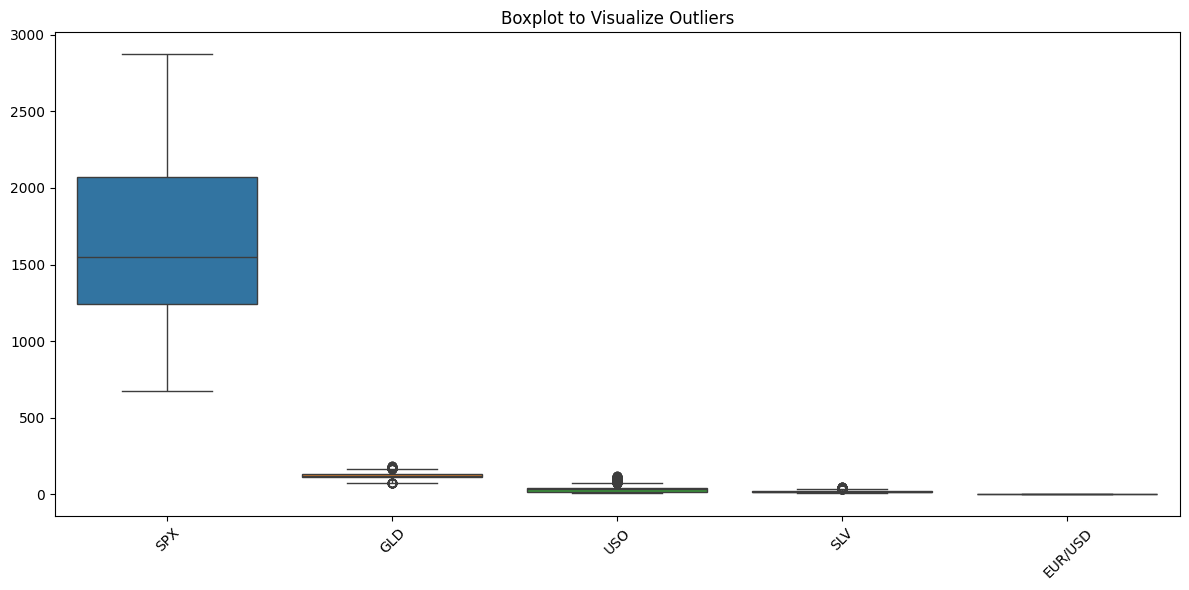

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Load data




# Step 2: Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Step 3: Compute Z-scores
z_scores = numeric_df.apply(zscore)

# Step 4: Count outliers per column
outliers = (abs(z_scores) > 3).sum()
print("Outlier counts per feature:\n", outliers)

# Step 5: Basic statistical summary
print("\nBasic Statistics:\n", numeric_df.describe())

# Step 6: Combine and display
summary_df = pd.concat([outliers.rename("Outlier_Count"), numeric_df.describe().T], axis=1)
print("\nCombined Summary:\n", summary_df)

# Step 7: Boxplot for visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_df)
plt.title("Boxplot to Visualize Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
